Projeto Data Battery Nasa

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_bat = pd.read_csv('C:\\Users\\Enuk\\OneDrive\\Documents\\Enuk\\Cursos\\Python\\Projeto Maio\\battery_dataset\\metadata.csv')
df_bat.head(2000)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1995,impedance,[2009. 7. 25. 7. 54. ...,24,B0034,191,1996,01996.csv,NaN,0.12534411179359725,0.14788025975931193
1996,discharge,[2009. 7. 25. 8. 26. ...,24,B0034,192,1997,01997.csv,1.353993472828928,NaN,NaN
1997,charge,[2009. 7. 25. 9. 20. ...,24,B0034,193,1998,01998.csv,NaN,NaN,NaN
1998,discharge,[2009. 7. 25. 12. 19. ...,24,B0034,194,1999,01999.csv,1.3577165116893766,NaN,NaN


Diagnostico inicial


In [118]:
print('Informações de tipo e Memória')
df_bat.info()


print('Contagem de valores nulos na tabela:')
print(df_bat.isnull().sum())

Informações de tipo e Memória
<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB
Contagem de valores nulos na tabela:
type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity         

Corringindo parametros de "tempo"

In [119]:
df_tempo =df_bat['start_time'].str.strip('[]').str.split(expand=True)

df_tempo.columns = ['year', 'month', 'day', 'hour', 'minute', 'second']
df_tempo = df_tempo.apply(pd.to_numeric)

df_bat['start_time'] = pd.to_datetime(df_tempo)


Start Time aparecendo NaT

In [120]:
df_bat['start_time'].head()

0   2010-07-21 15:00:35.093
1   2010-07-21 16:53:45.968
2   2010-07-21 17:25:40.671
3   2010-07-21 20:31:05.000
4   2010-07-21 21:02:56.984
Name: start_time, dtype: datetime64[ns]

Capacidade e Resistência das baterias.


In [121]:
df_capacity = df_bat['Capacity'].str.strip('[]')

df_capacity.columns = ['capacity']
df_capacity = df_capacity.apply(pd.to_numeric)

df_bat['Capacity'] = pd.to_numeric(df_bat['Capacity'].str.strip('[]'), errors='coerce')
df_bat['Capacity'].head()

0    1.674305
1         NaN
2         NaN
3         NaN
4    1.524366
Name: Capacity, dtype: float64

In [122]:
print("Total de valores não-nulos agora:", df_bat['Capacity'].notnull().sum())

Total de valores não-nulos agora: 2769


Resistência

In [123]:
df_bat['Re'] = pd.to_numeric(df_bat['Re'].str.strip('[]'), errors='coerce')
df_bat['Rct'] = pd.to_numeric(df_bat['Rct'].str.strip('[]'), errors='coerce')

print("Total de valores não-nulos agora:", df_bat['Re'].notnull().sum())
print("Total de valores não-nulos agora:", df_bat['Rct'].notnull().sum())

Total de valores não-nulos agora: 1947
Total de valores não-nulos agora: 1947


In [124]:
df_bat.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   type                 7565 non-null   str           
 1   start_time           7565 non-null   datetime64[ns]
 2   ambient_temperature  7565 non-null   int64         
 3   battery_id           7565 non-null   str           
 4   test_id              7565 non-null   int64         
 5   uid                  7565 non-null   int64         
 6   filename             7565 non-null   str           
 7   Capacity             2769 non-null   float64       
 8   Re                   1947 non-null   float64       
 9   Rct                  1947 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), str(3)
memory usage: 591.1 KB


Tempo de vida decorrido

In [125]:
df_bat['Vida_Util'] = (df_bat['start_time'] - df_bat.groupby('battery_id')['start_time'].transform('min'))
df_bat['Tempo_Horas'] = df_bat['Vida_Util'].dt.total_seconds() / 3600
df_bat[['battery_id', 'start_time', 'Tempo_Horas']].head(10)


,battery_id,start_time,Tempo_Horas
0,B0047,2010-07-21 15:00:35.093,0.000000
1,B0047,2010-07-21 16:53:45.968,1.886354
2,B0047,2010-07-21 17:25:40.671,2.418216
3,B0047,2010-07-21 20:31:05.000,5.508307
4,B0047,2010-07-21 21:02:56.984,6.039414
5,B0047,2010-07-21 22:38:43.484,7.635664
6,B0047,2010-07-22 01:40:06.218,10.658646
7,B0047,2010-07-22 03:14:53.218,12.238368
8,B0047,2010-07-22 06:16:21.781,15.262969
9,B0047,2010-07-22 07:50:21.625,16.829592


Grafico curva de degradação

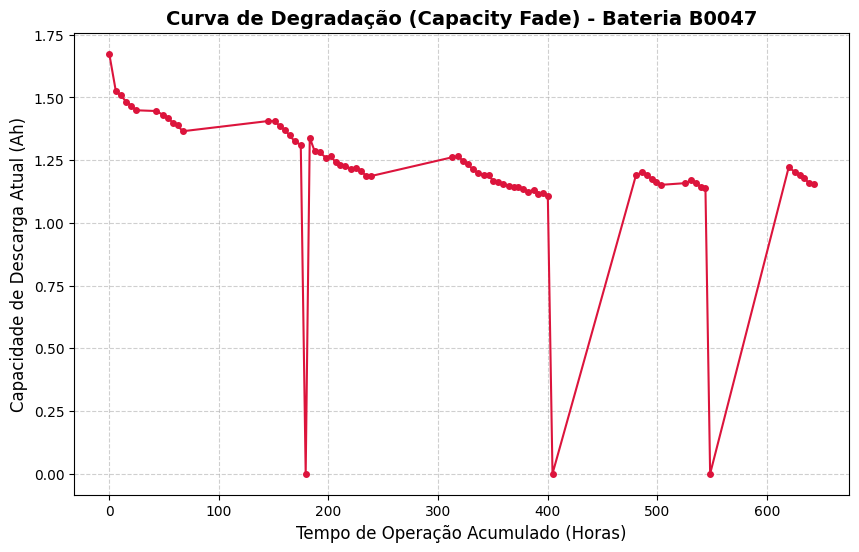

In [126]:
df_b47_descarga = df_bat[(df_bat['battery_id'] == 'B0047') & (df_bat['type'] == 'discharge')]

plt.figure(figsize=(10, 6))

plt.plot(df_b47_descarga['Tempo_Horas'], df_b47_descarga['Capacity'], marker='o', linestyle='-', color='crimson', markersize=4)

plt.title('Curva de Degradação (Capacity Fade) - Bateria B0047', fontsize=14, fontweight='bold')
plt.xlabel('Tempo de Operação Acumulado (Horas)', fontsize=12)
plt.ylabel('Capacidade de Descarga Atual (Ah)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Comparação entre 2 lotes de bateria

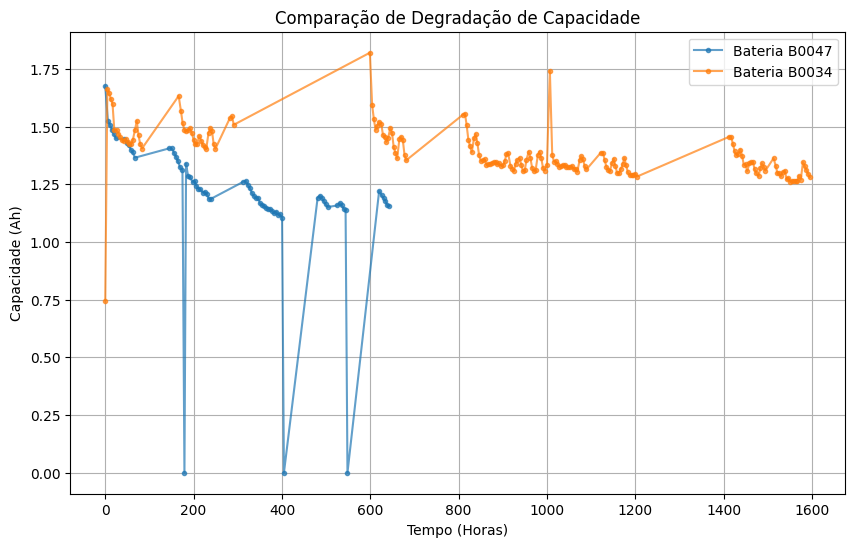

In [130]:
df_bat['Capacity'] = pd.to_numeric(df_bat['Capacity'].astype(str).str.strip('[]'), errors='coerce')

df_bat['Vida_Util'] = df_bat['start_time'] - df_bat.groupby('battery_id')['start_time'].transform('min')
df_bat['Tempo_Horas'] = df_bat['Vida_Util'].dt.total_seconds() / 3600

baterias_alvo = ['B0047', 'B0034']
plt.figure(figsize=(10, 6))

for bateria in baterias_alvo:

    df_temp = df_bat[(df_bat['battery_id'] == bateria) & (df_bat['type'] == 'discharge')]
    
    plt.plot(df_temp['Tempo_Horas'], df_temp['Capacity'], label=f"Bateria {bateria}", marker='o', markersize=3, alpha=0.7)

plt.legend() 
plt.title('Comparação de Degradação de Capacidade')
plt.xlabel('Tempo (Horas)')
plt.ylabel('Capacidade (Ah)')
plt.grid(True)
plt.show()

In [129]:
print("Quantas linhas tem o df_bat?", len(df_bat))

Quantas linhas tem o df_bat? 7565
